## Introduction to PyTorch and PyTorch Lightning

Welcome to this section focusing on **PyTorch** and **PyTorch Lightning**.

**PyTorch** is a widely used open-source machine learning framework known for its flexibility and ease of use, particularly for research and prototyping. You can find its official documentation here: [PyTorch Documentation](https://pytorch.org/).

**PyTorch Lightning** is a lightweight wrapper built on top of PyTorch that helps organize your PyTorch code and reduce boilerplate. It provides structure and automates many common tasks, making it easier to scale your models and conduct experiments. Learn more about PyTorch Lightning here: [PyTorch Lightning Documentation](https://lightning.ai/docs/pytorch/stable/).

In the following sections, we will explore how to use these tools for building and training neural networks.

In [ ]:
! pip install lightning
! pip install torchview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 60.2 MB/s eta 0:00:00


In [ ]:
# ===============================
# PyTorch Core Modules
# ===============================
import torch  # Core tensor operations
from torch import Tensor
import torch.nn as nn  # Neural network layers
import torch.nn.functional as F  # Functional API for activations, losses, etc.
import torch.optim as optim  # Optimizers
from torch.utils.data import Dataset, DataLoader, random_split  # Dataset utilities

# ===============================
# PyTorch Ecosystem
# ===============================
import pytorch_lightning as pl  # High-level training framework
import torchmetrics  # Model evaluation metrics
from torchview import draw_graph  # Model visualization
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor # Callbacks

# ===============================
# TorchVision - For image data
# ===============================
import torchvision  # Pretrained models and datasets
import torchvision.transforms as transforms  # Image preprocessing utilities
import torchvision.models as models

# ===============================
# Scikit-learn - Data generation and preprocessing
# ===============================
from sklearn.datasets import make_regression  # Synthetic regression data
from sklearn.model_selection import train_test_split  # Train/test splitting
from sklearn.preprocessing import MinMaxScaler  # Feature scaling

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt  # Plotting utilities

# ===============================
# Numerical Computing
# ===============================
import numpy as np  # Array operations
import math  # Basic mathematical functions

from PIL import Image
import requests
import io
import json

### Define a SimpleModel

Now that we have introduced the core libraries, let's start by defining a simple neural network using PyTorch's `nn.Module`. This `SimpleModel` will be a basic feedforward network, which is a fundamental building block in deep learning.

We define the model by inheriting from `nn.Module` and implementing two key methods:

-   `__init__`: **in order to** define the layers of the network. In this case, we have two linear layers (`nn.Linear`) and a ReLU activation function (`nn.ReLU`).
-   `forward`: **in order to** specify how data flows through the layers during a forward pass. The input `x` goes through the first linear layer, then the ReLU activation, and finally the second linear layer.

This simple model will serve as a foundation before we explore more complex architectures and the PyTorch Lightning framework.

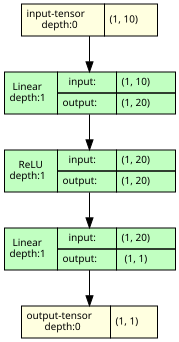

In [ ]:
class SimpleModel(nn.Module):
    """
    A simple feedforward neural network with one hidden layer.
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        # Linear layer: transforms input to hidden representation
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        # Non-linear activation function
        self.relu = nn.ReLU()
        # Linear layer: transforms hidden to output
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: Tensor) -> Tensor:
        """
        Forward pass through the network.
        """
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x


# Assuming input_dimension is 10
model_graph = draw_graph(
        model=SimpleModel(input_dim=10, hidden_dim=20, output_dim=1), # Pass the underlying PyTorch model
        input_data=torch.randn(1, 10),  # Create a dummy input tensor
        graph_name='SimpleModel Visualization' # Name for the generated graph
)

model_graph.visual_graph

Now that we've seen a basic PyTorch model (`SimpleModel`), let's look at the `SimpleLightningModule`. This class is built on top of PyTorch using **PyTorch Lightning**, a tool that helps organize our training code.

We use the `SimpleLightningModule` **in order to**:

*   **Wrap our standard PyTorch model:** It acts as a container for our `SimpleModel`.
*   **Define the training process in a structured way:** It provides dedicated methods for important steps like calculating the loss and configuring the optimizer.
*   **Leverage PyTorch Lightning's features:** Lightning handles many of the repetitive parts of the training loop, like moving data to the correct device (CPU/GPU), managing gradients, and logging important metrics.

Within the `SimpleLightningModule`, we define specific methods:

*   `__init__`: **in order to** set up our model and the way we'll measure how well it's doing (the loss function).
*   `forward`: **in order to** define how data flows through the model.
*   `training_step`: **in order to** specify what happens in one single step of training, including calculating the loss and logging it.
*   `configure_optimizers`: **in order to** tell PyTorch Lightning how to update the model's parameters based on the calculated loss.

By using `SimpleLightningModule`, we make our training code cleaner, more maintainable, and easier to scale for more complex projects.

In [ ]:
# Wrap the PyTorch model in a PyTorch Lightning module
class SimpleLightningModule(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = SimpleModel(input_dim, hidden_dim, output_dim)
        self.criterion = nn.MSELoss() # Mean Squared Error Loss

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.model(x)
        loss = self.criterion(y_pred, y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.model(x)
        loss = self.criterion(y_pred, y)
        self.log('val_loss', loss)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.model(x)
        loss = self.criterion(y_pred, y)
        self.log('test_loss', loss)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=0.001)
        return optimizer

# 3. Example usage (defining the module - training would require a Trainer and data)
simple_lightning_model = SimpleLightningModule(input_dim=10, hidden_dim=20, output_dim=1)

print("Simple PyTorch model wrapped in PyTorch Lightning:")
print(simple_lightning_model)

Simple PyTorch model wrapped in PyTorch Lightning:
SimpleLightningModule(
  (model): SimpleModel(
    (linear1): Linear(in_features=10, out_features=20, bias=True)
    (relu): ReLU()
    (linear2): Linear(in_features=20, out_features=1, bias=True)
  )
  (criterion): MSELoss()
)


Now that we have our `SimpleLightningModule`, let's see how to train, validate, and test it using the **PyTorch Lightning Trainer**.

The **Trainer** is the core object in PyTorch Lightning that automates the training loop and handles many details like:

*   Running training, validation, and testing epochs.
*   Moving data and models to the correct device (CPU/GPU).
*   Handling gradient accumulation, logging, and checkpoints.
*   Applying callbacks for things like learning rate scheduling or early stopping.

To train our `SimpleLightningModule`, we will:

1.  **Prepare Data:** Create dummy data using `torch.utils.data.Dataset` and `torch.utils.data.DataLoader` to simulate a real dataset.
2.  **Instantiate the Trainer:** Create a `pl.Trainer` object, specifying training parameters like the number of epochs.
3.  **Start Training:** Call the `trainer.fit()` method, passing our `LightningModule` and data loaders.
4.  **Validate (Optional but Recommended):** PyTorch Lightning can automatically run a validation step during training if you provide a validation dataloader and implement the `validation_step` method in your module.
5.  **Test:** After training, call `trainer.test()` to evaluate the model's performance on a separate test set.

In [ ]:
# Prepare dummy data (simulating a dataset)
class DummyDataset(Dataset):
    def __init__(self, num_samples=1500, input_dim=10, noise=10, random_state=42, split='train'):
        self.num_samples = num_samples
        self.input_dim = input_dim
        self.noise = noise
        self.random_state = random_state
        self.split = split # 'train', 'val', or 'test'

        # Generate synthetic data (only once)
        if not hasattr(DummyDataset, '_X_generated'):
            X, y = make_regression(n_samples=num_samples, n_features=input_dim, noise=noise, random_state=random_state)
            y = y.reshape(-1, 1)
            scaler = MinMaxScaler(feature_range=(-1, 1))
            y_scaled = scaler.fit_transform(y)
            y_scaled = y_scaled.flatten()

            # Store generated data as class attributes to avoid regenerating for each split
            DummyDataset._X_generated = X
            DummyDataset._y_generated = y_scaled

            # Split the data into training, validation, and test sets
            X_train, X_temp, y_train, y_temp = train_test_split(DummyDataset._X_generated, DummyDataset._y_generated, test_size=0.3, random_state=random_state)
            X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

            # Store split data as class attributes
            DummyDataset._X_train = X_train
            DummyDataset._y_train = y_train
            DummyDataset._X_val = X_val
            DummyDataset._y_val = y_val
            DummyDataset._X_test = X_test
            DummyDataset._y_test = y_test

        # Assign the correct split data to the instance
        if self.split == 'train':
            self.X = torch.from_numpy(DummyDataset._X_train).float()
            self.y = torch.from_numpy(DummyDataset._y_train).float().unsqueeze(1)
        elif self.split == 'val':
            self.X = torch.from_numpy(DummyDataset._X_val).float()
            self.y = torch.from_numpy(DummyDataset._y_val).float().unsqueeze(1)
        elif self.split == 'test':
            self.X = torch.from_numpy(DummyDataset._X_test).float()
            self.y = torch.from_numpy(DummyDataset._y_test).float().unsqueeze(1)
        else:
            raise ValueError("Invalid split specified. Choose 'train', 'val', or 'test'.")


    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dummy datasets and dataloaders
train_dataset_dummy = DummyDataset(split='train')
val_dataset_dummy = DummyDataset(split='val')
test_dataset_dummy = DummyDataset(split='test')

train_dataloader_dummy = DataLoader(train_dataset_dummy, batch_size=32, shuffle=True)
val_dataloader_dummy = DataLoader(val_dataset_dummy, batch_size=32)
test_dataloader_dummy = DataLoader(test_dataset_dummy, batch_size=32)



# Instantiate the SimpleLightningModule
model = SimpleLightningModule(input_dim=10, hidden_dim=20, output_dim=1)

# Instantiate the PyTorch Lightning Trainer
trainer = pl.Trainer(max_epochs=5)

# Start Training
print("Starting training...")
trainer.fit(model, train_dataloader_dummy, val_dataloader_dummy)

# Test the model
print("\nStarting testing...")
trainer.test(model, test_dataloader_dummy)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Starting training...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type        | Params | Mode 
--------------------------------------------------
0 | model     | SimpleModel | 241    | train
1 | criterion | MSELoss     | 0      | train
--------------------------------------------------
241       Trainable params
0         Non-trainable params
241       Total params
0.001     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (33) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.007498275022953749    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.007498275022953749}]

## End-to-End Example: Image Classification with CIFAR-10

In this section, we'll put together what we've learned to build an end-to-end example for image classification using the popular CIFAR-10 dataset.

We will cover:

1.  **Data Loading and Preprocessing:** Using `torchvision` to easily download and prepare the CIFAR-10 data.
2.  **Defining a Convolutional Neural Network (CNN):** Building a model specifically designed for image recognition tasks.
3.  **Implementing a PyTorch Lightning Module:** Integrating our CNN into a `LightningModule` to manage training, validation, and testing.
4.  **Training the Model:** Using the PyTorch Lightning `Trainer` to automate the training loop.

This example will demonstrate how to apply PyTorch and PyTorch Lightning to a common computer vision problem.

In [ ]:
# Define transformations for the data
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize pixel values
])

# Download and load the CIFAR-10 training dataset
train_val_dataset_c10 = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                 download=True, transform=transform)

# Split the training data into training and validation sets
train_size = int(0.8 * len(train_val_dataset_c10))
val_size = len(train_val_dataset_c10) - train_size
train_dataset_c10, val_dataset_c10 = random_split(train_val_dataset_c10, [train_size, val_size])

# Download and load the CIFAR-10 test dataset
test_dataset_c10 = torchvision.datasets.CIFAR10(root='./data', train=False,
                                                download=True, transform=transform)

# Create DataLoaders
train_dataloader_c10 = DataLoader(train_dataset_c10, batch_size=64, shuffle=True, num_workers=2)
val_dataloader_c10 = DataLoader(val_dataset_c10, batch_size=64, num_workers=2)
test_dataloader_c10 = DataLoader(test_dataset_c10, batch_size=64, num_workers=2)

# Get the number of classes and input channels
num_classes_c10 = len(test_dataset_c10.classes)
input_channels_c10 = 3 # CIFAR-10 images have 3 color channels (RGB)

print("CIFAR-10 data loaded and prepared.")
print(f"Number of classes: {num_classes_c10}")
print(f"Input channels: {input_channels_c10}")
print(f"Training data size: {len(train_dataset_c10)}")
print(f"Validation data size: {len(val_dataset_c10)}")
print(f"Test data size: {len(test_dataset_c10)}")

100%|██████████| 170M/170M [00:05<00:00, 29.0MB/s]


CIFAR-10 data loaded and prepared.
Number of classes: 10
Input channels: 3
Training data size: 40000
Validation data size: 10000
Test data size: 10000


### Understanding Convolution in Neural Networks

**Convolution** is a fundamental operation in neural networks, particularly in **Convolutional Neural Networks (CNNs)**. CNNs are designed to process data with a grid-like structure, such as images.

---

#### Why Use Convolutional Layers?

- **Automatic feature extraction**: Convolutional layers can learn relevant features directly from data.
- **Spatial awareness**: They preserve the spatial relationships between pixels, unlike fully connected layers that treat all inputs independently.
- **Parameter efficiency**: Convolutional layers use shared weights, resulting in fewer parameters and reduced computational cost.

---

#### Why Fully Connected Networks Fall Short for Images

Fully connected networks treat all input features equally and independently, ignoring spatial locality. For images, this means that neighboring pixel relationships are lost, making them inefficient and less effective for visual tasks.

---

#### Key Concepts and Hyperparameters

Let:

- $I$ = input size (height or width)
- $K$ = kernel size
- $P$ = amount of zero-padding
- $S$ = stride
- $C_{in}$ = number of input channels
- $C_{out}$ = number of output channels (filters)

The output size $O$ after a convolution operation is calculated as:

$$
O = \frac{(I - K + 2P)}{S} + 1
$$

---

#### Input and Output Shapes in 2D Convolution

Depending on the data format:

- **Channels first** (commonly used in PyTorch):
  $$
  \text{Input shape: } (batch\_size, C_{in}, I_1, I_2) \\
  \text{Output shape: } (batch\_size, C_{out}, O_1, O_2)
  $$

- **Channels last** (commonly used in TensorFlow/Keras):
  $$
  \text{Input shape: } (batch\_size, I_1, I_2, C_{in}) \\
  \text{Output shape: } (batch\_size, O_1, O_2, C_{out})
  $$

---

By using convolutional layers, CNNs are able to learn hierarchical features such as edges, textures, and complex shapes—making them highly effective for image and spatial data analysis.


In [ ]:
X = [512, 256, 100, 33]
Y = [512, 200, 250, 333]
K1 = [1, 3, 4, 5]
K2 = [1, 3, 3, 5]
S = [1, 1, 2, 3]
P = [0, 1, 0, 2]

for x, y, k1, k2, s, p in zip(X, Y, K1, K2, S, P):
  sample_input = torch.from_numpy(np.random.uniform(size=(1, 3, x, y)).astype(np.float32))
  out_shape = nn.Conv2d(in_channels=3, out_channels=9, kernel_size=(k1, k2), padding=p, stride=s)(sample_input).shape
  assert out_shape[0] == 1 # batch size
  assert out_shape[1] == 9 # out_channels
  assert out_shape[2] == 1 + (x - k1 + 2 * p) // s
  assert out_shape[3] == 1 + (y - k2 + 2 * p) // s

## Convolution animations

_N.B.: Blue maps are inputs, and cyan maps are outputs._

<table style="width:100%; table-layout:fixed;">
  <tr>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/no_padding_no_strides.gif"></td>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/arbitrary_padding_no_strides.gif"></td>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/same_padding_no_strides.gif"></td>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/full_padding_no_strides.gif"></td>
  </tr>
  <tr>
    <td>No padding, stride = 1</td>
    <td>Padding=2, stride = 1</td>
    <td>Padding=1, stride = 1</td>
    <td>Padding=3 (full), stride=1</td>
  </tr>
  <tr>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/no_padding_strides.gif"></td>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/padding_strides.gif"></td>
    <td><img width="150px" src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/padding_strides_odd.gif"></td>
    <td></td>
  </tr>
  <tr>
    <td>Stride = 2</td>
    <td>Padding = 1, Stride = 2</td>
    <td>Padding = 1, stride = 2 (I = 6)</td>
    <td></td>
  </tr>
</table>

[Vincent Dumoulin, Francesco Visin - A guide to convolution arithmetic for deep learning](https://github.com/vdumoulin/conv_arithmetic)

Now let's define the [CNN](https://www.datacamp.com/tutorial/introduction-to-convolutional-neural-networks-cnns)

- We define a `SimpleCNN` class inheriting from nn.Module.
- It consists of two convolutional blocks, each with a Conv2d layer, a [ReLU activation](https://www.geeksforgeeks.org/relu-activation-function-in-deep-learning/), and a [MaxPool2d layer](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html). Convolutional layers are good at extracting spatial features from images.
- After the convolutional layers, the tensor is flattened (`torch.flatten`) to be fed into fully connected (`nn.Linear`) layers.
- The output layer (`self.fc2`) has num_classes output features, corresponding to the scores for each class.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 input channels, 32 output channels, 3x3 kernel
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pooling

        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 input channels, 64 output channels
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # The size of the input to the first fully connected layer depends on the output of the convolutional layers
        # For CIFAR-10 (32x32 images), after two conv/pool layers, the spatial dimensions become 32/2/2 = 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 128) # 64 channels * 8x8 spatial dimensions
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes) # Output layer with num_classes for classification

    def forward(self, x):
        # Apply first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)

        # Apply second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.maxpool2(x)

        # Flatten the tensor for the fully connected layers
        x = torch.flatten(x, 1) # Flatten starting from dimension 1 (batch dimension is 0)

        # Apply fully connected layers
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)

        return x

# Instantiate the CNN model
cnn_model = SimpleCNN(num_classes=10) # CIFAR-10 has 10 classes

print("Simple CNN Model defined:")
print(cnn_model)

Simple CNN Model defined:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


We're now implementing the Lightning Module

- We define `CIFAR10LightningModule` inheriting from pl.LightningModule.
- `self.save_hyperparameters() `automatically saves the arguments passed to __init__ (like num_classes and learning_rate) as `self.hparams`.
- We define the `self.model` (our `SimpleCNN`), the `self.criterion` (CrossEntropyLoss for classification), and a metric (`torchmetrics.Accuracy`).
- `training_step`, `validation_step`, and `test_step` implement the logic for each phase, calculating the loss and logging both loss and accuracy.
- `configure_optimizers` sets up the Adam optimizer, using the saved learning rate from `self.hparams`.


In [ ]:
class CIFAR10LightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters() # Saves hyperparameters like num_classes and learning_rate
        self.model = SimpleCNN(num_classes) # Our CNN model
        self.criterion = nn.CrossEntropyLoss() # Loss function for classification
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes) # Metric for accuracy

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss)
        self.log('train_acc', self.accuracy(outputs, labels))
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss)
        self.log('val_acc', self.accuracy(outputs, labels))
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

# Instantiate the Lightning Module
cifar10_model = CIFAR10LightningModule(num_classes=10)

print("CIFAR10 Lightning Module defined.")
print(cifar10_model)

CIFAR10 Lightning Module defined.
CIFAR10LightningModule(
  (model): SimpleCNN(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc1): Linear(in_features=4096, out_features=128, bias=True)
    (relu3): ReLU()
    (fc2): Linear(in_features=128, out_features=10, bias=True)
  )
  (criterion): CrossEntropyLoss()
  (accuracy): MulticlassAccuracy()
)


## Visualizing the CIFAR-10 Lightning Module

We can use `torchview` to visualize the architecture of our `CIFAR10LightningModule`, which wraps the `SimpleCNN`. This helps in understanding the flow of data through the layers of the CNN.

We will create a dummy input tensor matching the expected input shape of a CIFAR-10 image and then use `draw_graph` to generate the plot.

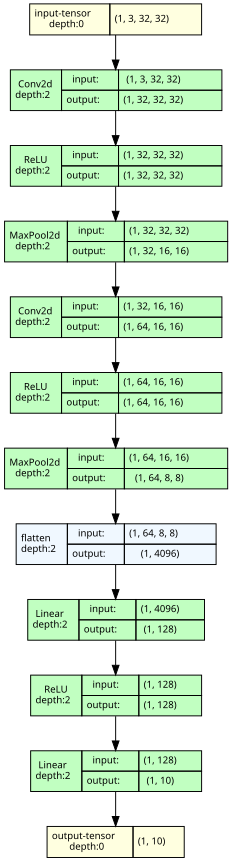

In [ ]:
# Instantiate the CIFAR10LightningModule
# We need to provide the same parameters as when it was defined
cifar10_model_for_graph = CIFAR10LightningModule(num_classes=10)

# Create a dummy input tensor for CIFAR-10 images
# CIFAR-10 images are 3 channels (RGB) and 32x32 pixels
dummy_input_cifar = torch.randn(1, 3, 32, 32)

# Use draw_graph to visualize the CIFAR10LightningModule
cifar10_model_graph = draw_graph(
    model=cifar10_model_for_graph,
    input_data=dummy_input_cifar,
    graph_name='CIFAR10 Lightning Module Visualization', # Name for the generated graph
    # Set depth to a higher value if you want to see more nested modules
    depth=3 # Adjust this to see more or less detail of the nested SimpleCNN
)

# Display the visual graph
cifar10_model_graph.visual_graph

We're now introducing the trainer

- We instantiate various pytorch lightning [callbacks](https://lightning.ai/docs/pytorch/stable/extensions/callbacks.html): We create instances of each callback:
  - `ModelCheckpoint`: Configured to monitor the validation accuracy (`'val_acc'`) and save the model checkpoint with the highest validation accuracy. It saves to a directory named `checkpoints/` and the filename will be `best-cifar10-model.ckpt`. `save_top_k=1` ensures only the single best model is kept.
  - `EarlyStopping`: Configured to monitor the validation loss (`'val_loss'`) and stop training if the loss doesn't decrease for 3 consecutive epochs (`patience=3`).
  - `LearningRateMonitor`: Configured to log the current learning rate at each training step.
- We instantiate the `pl.Trainer`.
  - `max_epochs` sets the number of training epochs.
  - `accelerator='auto'` tells Lightning to automatically use a GPU if available (recommended), otherwise it defaults to CPU.
  - `devices=1` specifies to use one device.
  - `trainer.fit()` starts the training process, using the provided Lightning module and data loaders.
  - `trainer.test()` evaluates the trained model on the test set after training is complete.


In [ ]:
# Model Checkpoint Callback
# Saves the model's weights based on a monitored metric (e.g., validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc', # Metric to monitor
    mode='max',        # 'max' means we want to maximize the monitored metric
    dirpath='checkpoints/', # Directory to save checkpoints
    filename='best-cifar10-model', # Name for the checkpoint file
    save_top_k=1,      # Save only the best model based on the monitored metric
    verbose=True       # Print a message when a checkpoint is saved
)

# Early Stopping Callback
# Stops training early if the monitored metric doesn't improve for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    mode='min',         # 'min' means we want to minimize the monitored metric
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    verbose=True        # Print a message when early stopping is triggered
)

# Learning Rate Monitor Callback
# Logs the learning rate during training. Useful for learning rate scheduling.
lr_monitor_callback = LearningRateMonitor(logging_interval='step') # Log learning rate at each step

# Instantiate the PyTorch Lightning Trainer
# You can configure various options here, e.g., gpus, max_epochs, etc.
trainer = pl.Trainer(
    max_epochs=10, # Train for a few more epochs to see callbacks in action
    accelerator='auto', # Use GPU if available, otherwise CPU
    devices=1,  # Use 1 device (GPU or CPU)
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback] # Pass the list of callbacks to the Trainer
)

# Start Training
print("Starting CIFAR-10 training with callbacks...")
trainer.fit(cifar10_model, train_dataloader_c10, val_dataloader_c10)

# Test the model after training
print("\nStarting CIFAR-10 testing...")

# For simplicity here, we just test the model in its final state after training
trainer.test(cifar10_model, test_dataloader_c10)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | SimpleCNN          | 545 K  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | accuracy  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
545 K     Trainable params
0         Non-trainable params
545 K     Total params
2.180     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Starting CIFAR-10 training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 3 records. Best score: 0.814. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 7, global step 5000: 'val_acc' was not in top 1
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting CIFAR-10 testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7091000080108643     │
│         test_loss         │    0.9724254608154297     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.9724254608154297, 'test_acc': 0.7091000080108643}]

### Examining CIFAR-10 Test Results

Following the training and testing of our CIFAR-10 model, this section visualizes several test images. We'll display the images alongside their true labels and the model's predictions to evaluate its performance on individual examples.

Plotting some test samples from CIFAR-10 with predictions:


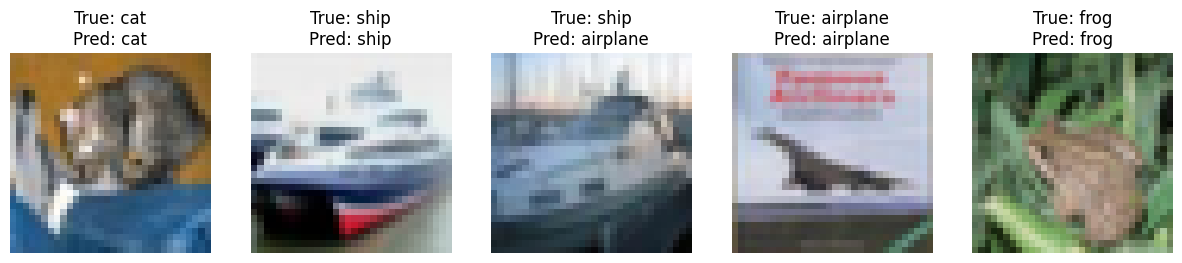

In [ ]:
# Plot some test samples and their predictions
print("Plotting some test samples from CIFAR-10 with predictions:")

# Get one batch of test data from the CIFAR-10 test_dataloader
test_images_cifar, test_labels_cifar = next(iter(test_dataloader_c10))

# Move images to the same device as the model and get predictions
# Assuming cifar10_model is already instantiated and trained
device = next(cifar10_model.parameters()).device # Get the device of the model
test_images_cifar = test_images_cifar.to(device)

with torch.no_grad(): # No need to calculate gradients for inference
    outputs = cifar10_model(test_images_cifar)
    # Get the index of the class with the highest probability
    _, predicted_labels_cifar = torch.max(outputs, 1)

# Move data back to CPU for plotting if needed
test_images_cifar = test_images_cifar.cpu()
test_labels_cifar = test_labels_cifar.cpu()
predicted_labels_cifar = predicted_labels_cifar.cpu()

# Display the first few images with true and predicted labels
fig_cifar, axes_cifar = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # Unnormalize the image for display (CIFAR-10 normalization used mean and std of 0.5)
    img_cifar = test_images_cifar[i] * 0.5 + 0.5     # Unnormalize
    npimg_cifar = img_cifar.numpy()
    # Matplotlib expects shape (height, width, channels)
    npimg_cifar = np.transpose(npimg_cifar, (1, 2, 0))

    axes_cifar[i].imshow(npimg_cifar)
    axes_cifar[i].set_title(f"True: {test_dataset_c10.classes[test_labels_cifar[i]]}\nPred: {test_dataset_c10.classes[predicted_labels_cifar[i]]}")
    axes_cifar[i].axis('off')

plt.show()

## Pretrained Classification Architectures in TorchVision

**TorchVision** is a part of the PyTorch project that provides access to popular datasets, model architectures, and image transformations for computer vision. It's an invaluable resource for quickly getting started with state-of-the-art models.

One of the key features of TorchVision is the availability of **pretrained models**. These are models that have already been trained on large datasets like ImageNet (a dataset with millions of images across 1000 categories). Using a pretrained model can be very beneficial because:

- **Transfer Learning:** The model has already learned powerful features from a vast amount of data, which can be transferred to a new, related task with less data.
- **Faster Convergence:** Starting from a pretrained model usually leads to faster training and better performance compared to training from scratch.
- **Reduced Computational Cost:** You don't need to train a large model on a massive dataset yourself.

TorchVision provides a wide range of popular classification architectures, including:

- **[ResNet (Residual Networks)](https://arxiv.org/abs/1512.03385):** Known for using residual connections to train very deep networks.
- **[EfficientNet](https://arxiv.org/abs/1905.11946):** A family of models that achieve high accuracy with better efficiency by uniformly scaling network depth, width, and resolution.
- **VGG:** Simple and effective models with multiple convolutional layers followed by max pooling.
- **Inception (GoogleNet):** Models that use "inception modules" to capture features at different scales.
- **DenseNet:** Networks where each layer is connected to every other layer in a feed-forward fashion.

You can find the full list of available models and their documentation here: [TorchVision Models Documentation](https://pytorch.org/vision/stable/models.html).

In [ ]:
# Load a pretrained ResNet18 model
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Download an example image from a different source
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg" # Using an image from PyTorch examples on GitHub
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

# Use io.BytesIO to treat the content as a file
img = Image.open(io.BytesIO(response.content)).convert("RGB")

# Define the necessary transformations for the model (ImageNet specific)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Preprocess the image
input_tensor = preprocess(img)
# Add a batch dimension
input_batch = input_tensor.unsqueeze(0)

# Put the model in evaluation mode (important for consistent behavior with dropout, batchnorm, etc.)
resnet18.eval()

# Move the input to the same device as the model (if using GPU)
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    resnet18.to('cuda')

# Get predictions (logits) from the ResNet18 model
with torch.no_grad(): # No need to calculate gradients for inference
    output = resnet18(input_batch)

# The output has unnormalized probabilities. To get the predicted class, apply softmax.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Get the ImageNet class labels
# Download the ImageNet class index to label mapping file
imagenet_labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(imagenet_labels_url)
response.raise_for_status() # Raise an exception for bad status codes

# Load the class labels
imagenet_classes = response.text.splitlines()

# Get the top 5 predictions
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\nTop 5 predictions for the image:")
# Display the class names using the loaded mapping
for i in range(top5_prob.size(0)):
    print(f"  Class Name: {imagenet_classes[top5_catid[i].item()]}, Probability: {top5_prob[i].item():.4f}")

display(img)

Output hidden; open in https://colab.research.google.com to view.

## Object Detection with TorchVision

**Object Detection** is a computer vision task that involves identifying and locating objects within an image. Unlike image classification, which assigns a single label to an entire image, object detection aims to draw bounding boxes around each object of interest and classify what that object is.

**TorchVision** provides convenient access to several state-of-the-art object detection models, pretrained on datasets like COCO (Common Objects in Context). Using these pretrained models allows you to quickly apply powerful object detection capabilities without training from scratch.

Common object detection architectures available in TorchVision include:

-   **Faster R-CNN:** A popular two-stage detector that first proposes regions of interest and then classifies and refines the bounding boxes for each region.
-   **SSD (Single Shot MultiBox Detector):** A single-stage detector that predicts bounding boxes and class probabilities directly from feature maps in a single pass.
-   **RetinaNet:** Another single-stage detector that uses a focal loss function to address the class imbalance problem.

You can find more details and available models in the TorchVision documentation: [TorchVision Object Detection Models](https://docs.pytorch.org/vision/main/models.html#object-detection).


Object detection inference complete.
Prediction output structure (for the first image in the batch):
dict_keys(['boxes', 'labels', 'scores'])
Number of detected objects: 3


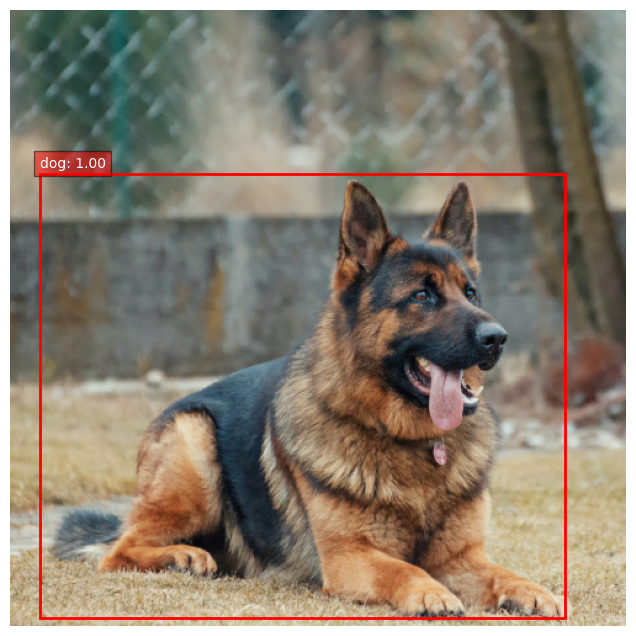

In [ ]:
# Load a pretrained Faster R-CNN model with a ResNet50 backbone
fasterrcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

fasterrcnn_model.eval()

# Download a sample image for object detection
url = "https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg"
response = requests.get(url)
response.raise_for_status()

# Open the image using PIL
img = Image.open(io.BytesIO(response.content)).convert("RGB")

# For this pretrained model, converting to tensor is sufficient for inference
transform = transforms.Compose([
    transforms.ToTensor()
])

# Apply the transform to the image
input_tensor = transform(img)

# Add a batch dimension (models expect input in the format [batch_size, channels, height, width])
input_batch = input_tensor.unsqueeze(0)

# Move the input to the same device as the model (if using GPU)
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    fasterrcnn_model.to('cuda')

# Perform inference
# The model returns a list of dictionaries, one for each image in the batch.
# Each dictionary contains 'boxes', 'labels', and 'scores'.
with torch.no_grad():
    prediction = fasterrcnn_model(input_batch)

print("\nObject detection inference complete.")
print("Prediction output structure (for the first image in the batch):")
print(prediction[0].keys())
print(f"Number of detected objects: {len(prediction[0]['boxes'])}")

response = requests.get("https://gist.githubusercontent.com/tersekmatija/9d00c4683d52d94cf348acae29e8db1a/raw/8d1b042e7dd6061c760422f51e8e8488c6ad68c7/coco-labels-91.txt")
response.raise_for_status()

# COCO class labels
COCO_INSTANCE_CATEGORY_NAMES = response.text.split("\n")

def plot_results(pil_img, prediction, score_threshold=0.5):
    """
    Plots the bounding boxes and labels on the image.
    """

    plt.figure(figsize=(12, 8))
    plt.imshow(pil_img)
    ax = plt.gca()

    # Iterate through the detections and plot boxes and labels with confidence scores
    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        if score > score_threshold: # Only plot detections above the confidence threshold
            xmin, ymin, xmax, ymax = box.tolist()
            # Create a Rectangle patch
            rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 fill=False, color='red', linewidth=2)
            ax.add_patch(rect)

            # Get the class name
            class_name = COCO_INSTANCE_CATEGORY_NAMES[label.item() - 1]

            # Add the label and score text
            label_text = f"{class_name}: {score:.2f}"
            ax.text(xmin, ymin - 5, label_text, bbox=dict(facecolor='red', alpha=0.5), fontsize=10, color='white')

    plt.axis('off')
    plt.show()

# Visualize the predictions on the image
# We need to pass the original PIL image and the prediction output
# Ensure the prediction is on the CPU for plotting if it was on GPU
prediction_cpu = {k: v.cpu() for k, v in prediction[0].items()}
plot_results(img, prediction_cpu, score_threshold=0.7) # Adjust score_threshold as needed

## Image Segmentation with TorchVision

**Image Segmentation** is a computer vision task that involves partitioning an image into multiple segments or regions, often to locate objects and boundaries in an image. Each pixel in the image is assigned a class label. Unlike object detection, which outputs bounding boxes, segmentation provides a more detailed, pixel-level understanding of the image content.

**TorchVision** offers several state-of-the-art image segmentation models, pretrained on datasets like COCO, that you can use for various applications.

One of the popular segmentation architectures available in TorchVision is:

- **DeepLabV3:** A semantic segmentation model that uses atrous convolutions to capture multi-scale context.

You can find more details and available models in the TorchVision documentation: [TorchVision Segmentation Models](https://docs.pytorch.org/vision/main/models.html#semantic-segmentation).


Image segmentation inference complete.
Output shape: torch.Size([1, 21, 1026, 1282])


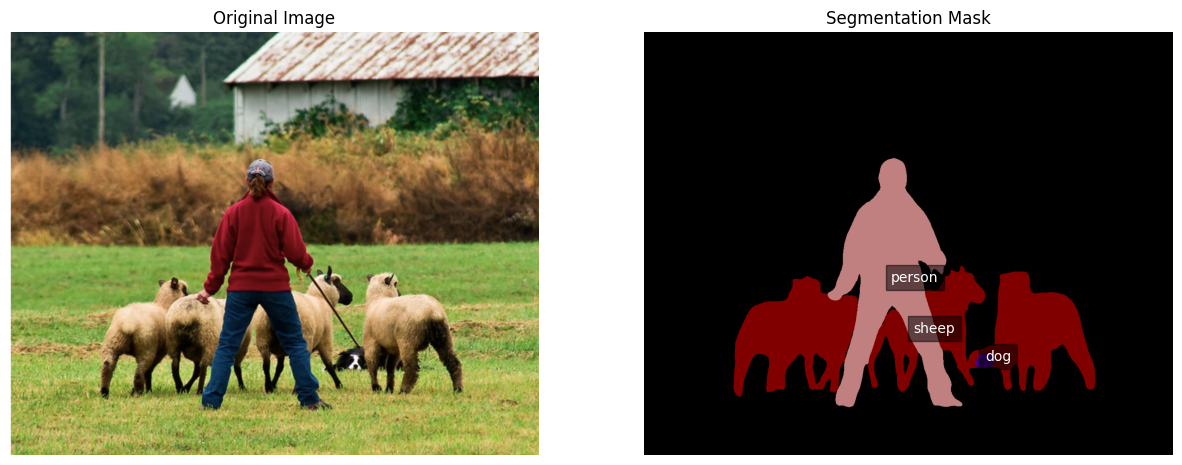

In [ ]:
# Load a pretrained DeepLabV3 model with a ResNet101 backbone
# We set weights to DEFAULT to load the pretrained weights
deeplabv3_model = torchvision.models.segmentation.deeplabv3_resnet101(weights=torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT)

deeplabv3_model.eval() # Set the model to evaluation mode

# Download a sample image for segmentation
# Using a different image that is suitable for segmentation
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/deeplab1.png"
response = requests.get(url)
response.raise_for_status()

# Open the image using PIL
img_seg = Image.open(io.BytesIO(response.content)).convert("RGB")

# Define the necessary transformations for the model (ImageNet specific for backbone)
preprocess_seg = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Preprocess the image
input_tensor_seg = preprocess_seg(img_seg)
# Add a batch dimension
input_batch_seg = input_tensor_seg.unsqueeze(0)

# Move the input to the same device as the model (if using GPU)
if torch.cuda.is_available():
    input_batch_seg = input_batch_seg.to('cuda')
    deeplabv3_model.to('cuda')

# Perform inference
# The model returns a dictionary with 'out' being the output segmentation mask
with torch.no_grad():
    output_seg = deeplabv3_model(input_batch_seg)['out']

print("\nImage segmentation inference complete.")
print("Output shape:", output_seg.shape)

# The output is a tensor of logits. We need to apply softmax and get the class with the highest probability for each pixel.
# The shape is [batch_size, num_classes, height, width]
# We take the argmax along dimension 1 (the class dimension) to get the predicted class index for each pixel.
predicted_mask = output_seg.argmax(1).squeeze(0) # Remove batch dimension and get the mask

# Move the predicted mask back to CPU for visualization
predicted_mask_cpu = predicted_mask.cpu()

# --- Visualization ---
# Load the COCO segmentation class labels
# Using a generic list of colors for visualization
palette = [
    0, 0, 0, 128, 0, 0, 0, 128, 0, 128, 128, 0, 0, 0, 128, 128, 0, 128,
    0, 128, 128, 128, 128, 128, 64, 0, 0, 192, 0, 0, 64, 128, 0, 192,
    128, 0, 64, 0, 128, 192, 0, 128, 64, 128, 128, 192, 128, 128
]
# Extend the palette if needed for more classes
palette = palette * 10 # Repeat the pattern

# COCO segmentation class names (simplified list for visualization)
# The full list has 21 classes including background
COCO_SEG_CLASSES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]


def visualize_segmentation(pil_img, predicted_mask, class_names, palette):
    """
    Visualizes the original image and the segmentation mask with class labels.
    """
    # Create a PIL image from the predicted mask
    mask_img = Image.fromarray(predicted_mask.byte().numpy())
    mask_img.putpalette(palette)

    fig, axes = plt.subplots(1, 2, figsize=(15, 8))

    axes[0].imshow(pil_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(mask_img)
    axes[1].set_title("Segmentation Mask")
    axes[1].axis('off')

    # Add class labels to the segmentation mask plot
    # Find unique class indices in the mask
    unique_classes = torch.unique(predicted_mask)

    for class_idx in unique_classes:
        if class_idx.item() == 0: # Skip background
            continue
        # Get the class name
        class_name = class_names[class_idx.item()]

        # Find the centroid of the segmented region for placing the text
        # This is a simple approach; more sophisticated methods exist
        mask_coords = (predicted_mask == class_idx).nonzero(as_tuple=False)
        if mask_coords.numel() > 0:
            y_center, x_center = mask_coords.float().mean(dim=0).int().tolist()
            axes[1].text(x_center, y_center, class_name, color='white', fontsize=10,
                         bbox=dict(facecolor='black', alpha=0.5))


    plt.show()

# Visualize the results with class labels
visualize_segmentation(img_seg, predicted_mask_cpu, COCO_SEG_CLASSES, palette)

# Assignment: Image Classification Model Benchmarking

## Objective
Train and evaluate different image classification models on the **Plant Type Dataset** from Kaggle using **PyTorch** and **PyTorch Lightning**. Benchmark their performance and analyze results.

## Tasks

1. **Dataset**
   - Use the [Plant Type Dataset](https://www.kaggle.com/datasets/yudhaislamisulistya/plants-type-datasets).
   - Load and preprocess with `torch.utils.data.Dataset` and `DataLoader`.
   - Apply transforms (resize, normalization, augmentation).

2. **Models**
   - Implement at least **two models**:
     - A **SimpleCNN** (baseline).
     - A **pretrained model** (e.g., ResNet, VGG, or MobileNet).
   - Fine-tune pretrained weights for better performance.

3. **PyTorch Lightning**
   - Wrap models in a `LightningModule`.
   - Define `training_step`, `validation_step`, and `test_step`.
   - Use callbacks like `ModelCheckpoint` and `EarlyStopping`.

4. **Training & Evaluation**
   - Train on the training set, tune with validation data.
   - Evaluate final models on the test set.
   - Compare metrics and analyze results.

## Evaluation Metrics
- **Accuracy**
- **Loss**
- Precision, Recall, F1-score, Confusion Matrix.

## Deliverable
A well-documented **Colab notebook** including:
- Data loading and preprocessing code.
- Model implementation and training with Lightning.
- Evaluation results and visualizations.
- Instructions for accessing the Kaggle dataset (via Kaggle API or upload).

## Tips
- Install Kaggle API: `!pip install kaggle`
- Start with simpler models or pretrained models to get a baseline.
- Experiment with learning rate, batch size, and epochs.
- Refer to the PyTorch and TorchVision documentation for details on datasets, models, and transforms.
